In [1]:
import json
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

load_dotenv('../.env')

s3 = boto3.client(
    's3',
    endpoint_url=os.getenv('MINIO_ENDPOINT', 'http://localhost:9000'),
    aws_access_key_id=os.getenv('MINIO_ACCESS_KEY', 'minioadmin'),
    aws_secret_access_key=os.getenv('MINIO_SECRET_KEY', 'minioadmin'),
    region_name='us-east-1',
)

BUCKET = os.getenv('MINIO_BUCKET_PROCESSED', 'healthcare-processed')
print("✓ Setup completo")

✓ Setup completo


In [2]:
import json
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv('../.env')

s3 = boto3.client(
    's3',
    endpoint_url=os.getenv('MINIO_ENDPOINT', 'http://localhost:9000'),
    aws_access_key_id=os.getenv('MINIO_ACCESS_KEY', 'minioadmin'),
    aws_secret_access_key=os.getenv('MINIO_SECRET_KEY', 'minioadmin'),
    region_name='us-east-1',
)

def load_minio(bucket: str) -> list:
    paginator = s3.get_paginator('list_objects_v2')
    records = []
    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            try:
                r = s3.get_object(Bucket=bucket, Key=obj['Key'])
                event = json.loads(r['Body'].read())
                if 'risk_level' in event:
                    records.append(event)
            except:
                pass
    return records

def load_kaggle() -> list:
    path = '../data/sample_data/kaggle_enriched_events.json'
    with open(path) as f:
        return json.load(f)

# Cargar ambas fuentes
faker_records  = load_minio(os.getenv('MINIO_BUCKET_PROCESSED', 'healthcare-processed'))
kaggle_records = load_kaggle()

df_faker  = pd.DataFrame(faker_records)
df_kaggle = pd.DataFrame(kaggle_records)

# Combinar
df = pd.concat([df_faker, df_kaggle], ignore_index=True)

print(f"✓ Faker events:  {len(df_faker)}")
print(f"✓ Kaggle events: {len(df_kaggle)}")
print(f"✓ Total:         {len(df)}")
print(f"✓ Columnas:      {df.shape[1]}")

✓ Faker events:  746
✓ Kaggle events: 300
✓ Total:         1046
✓ Columnas:      50


In [3]:
print("=== Fuentes de datos ===")
print(df['source'].value_counts() if 'source' in df.columns else "sin columna source")
print()
print("=== Balance ml_label ===")
print(df['ml_label'].value_counts())
print()
print("=== Complicaciones Kaggle ===")
if 'kaggle_complications' in df.columns:
    print(df['kaggle_complications'].value_counts())
print()
print("=== Stats básicas ===")
print(df[['patient_age','patient_bmi','ml_label']].describe().round(2))

=== Fuentes de datos ===
source
kaggle    300
Name: count, dtype: int64

=== Balance ml_label ===
ml_label
0    774
1    272
Name: count, dtype: int64

=== Complicaciones Kaggle ===
kaggle_complications
Respiratory distress     83
Nausea, mild bleeding    80
nan                      73
Delayed recovery         64
Name: count, dtype: int64

=== Stats básicas ===
       patient_age  patient_bmi  ml_label
count      1046.00      1046.00   1046.00
mean         47.75        29.07      0.26
std          15.98         6.53      0.44
min          16.00        17.50      0.00
25%          33.25        24.00      0.00
50%          49.50        28.00      0.00
75%          61.00        33.78      1.00
max          72.00        41.90      1.00


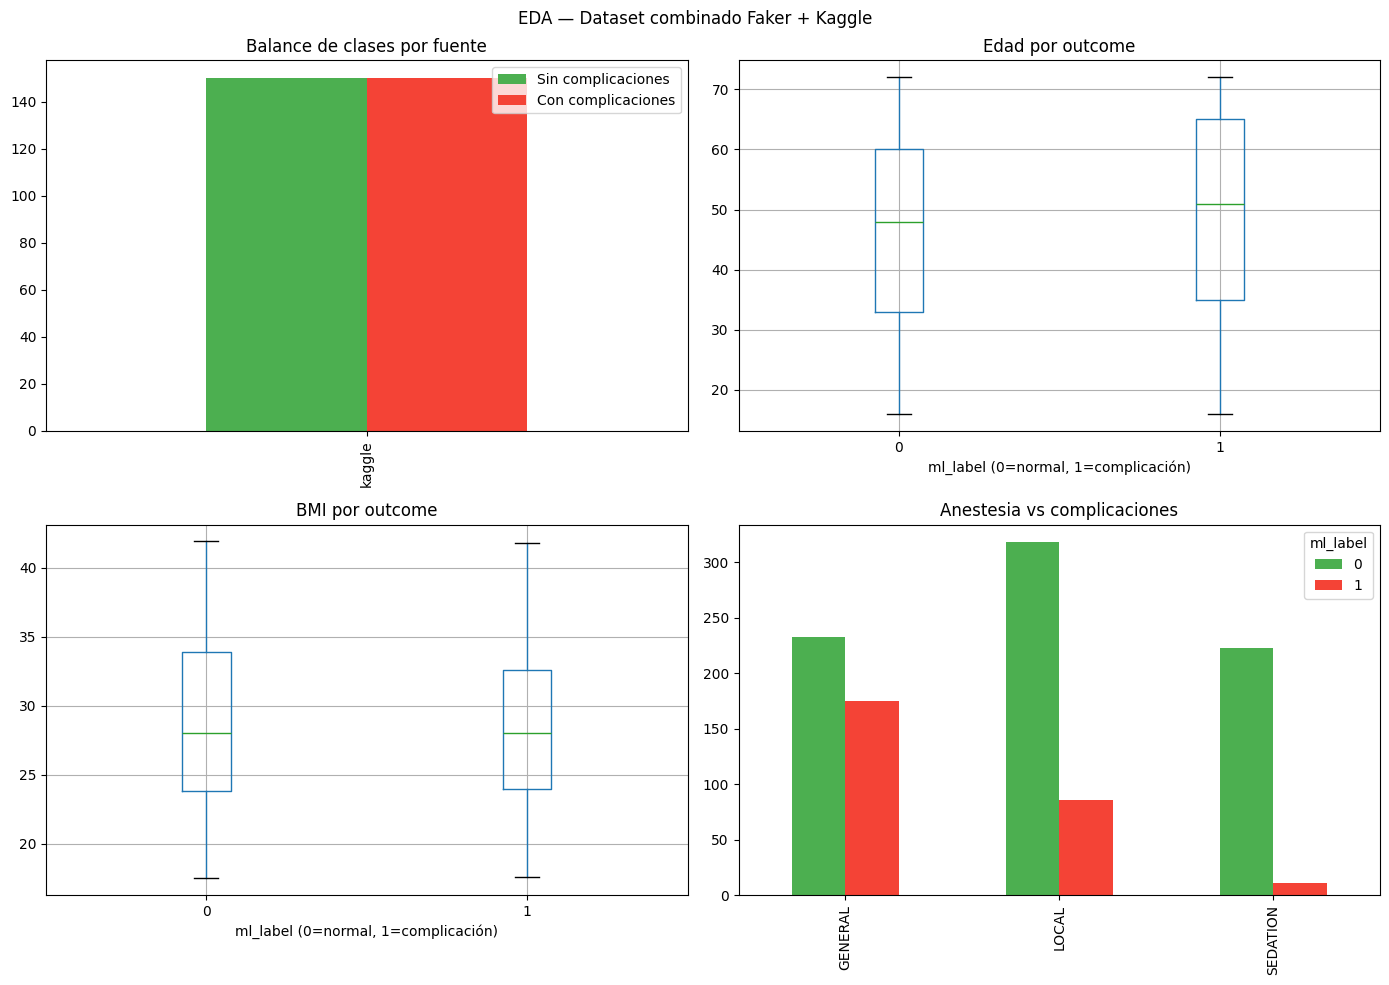

✓ Guardado eda_combined.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Balance de clases por fuente
sources = df.groupby(['source', 'ml_label']).size().unstack(fill_value=0) if 'source' in df.columns else None
if sources is not None:
    sources.plot(kind='bar', ax=axes[0,0], color=['#4CAF50','#F44336'])
    axes[0,0].set_title('Balance de clases por fuente')
    axes[0,0].set_xlabel('')
    axes[0,0].legend(['Sin complicaciones','Con complicaciones'])

# 2. Distribución de edad por outcome
df.boxplot(column='patient_age', by='ml_label', ax=axes[0,1])
axes[0,1].set_title('Edad por outcome')
axes[0,1].set_xlabel('ml_label (0=normal, 1=complicación)')

# 3. BMI por outcome
df.boxplot(column='patient_bmi', by='ml_label', ax=axes[1,0])
axes[1,0].set_title('BMI por outcome')
axes[1,0].set_xlabel('ml_label (0=normal, 1=complicación)')

# 4. Tipo de anestesia vs complicaciones
anes = df.groupby(['anesthesia_type','ml_label']).size().unstack(fill_value=0)
anes.plot(kind='bar', ax=axes[1,1], color=['#4CAF50','#F44336'])
axes[1,1].set_title('Anestesia vs complicaciones')
axes[1,1].set_xlabel('')

plt.suptitle('EDA — Dataset combinado Faker + Kaggle')
plt.tight_layout()
plt.savefig('eda_combined.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Guardado eda_combined.png")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

FEATURES = [
    'patient_age', 'patient_bmi', 'estimated_duration_min',
    'consent_to_surgery_hours', 'missing_fields_count',
    'previous_surgeries', 'risk_acknowledgement',
    'is_minor', 'smoker', 'diabetic', 'hypertensive',
    'has_allergies', 'pre_op_labs_completed', 'consent_signed',
    'witness_present', 'surgery_complexity',
]

CATEGORICAL = ['procedure_type', 'anesthesia_type', 'pre_op_clearance',
               'consent_channel', 'patient_gender']

df_ml = df.copy()

# Encodear categóricas
le = LabelEncoder()
for col in CATEGORICAL:
    if col in df_ml.columns:
        df_ml[col + '_enc'] = le.fit_transform(df_ml[col].fillna('UNKNOWN').astype(str))
        FEATURES.append(col + '_enc')

# Kaggle features extra
if 'kaggle_pain_level' in df_ml.columns:
    FEATURES.append('kaggle_pain_level')
    df_ml['kaggle_pain_level'] = df_ml['kaggle_pain_level'].fillna(0)

# Booleanos a int
bool_cols = ['is_minor','smoker','diabetic','hypertensive',
             'has_allergies','pre_op_labs_completed','consent_signed','witness_present']
for col in bool_cols:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].astype(bool).astype(int)

X = df_ml[[f for f in FEATURES if f in df_ml.columns]].fillna(0)
y = df_ml['ml_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Features usadas: {len(X.columns)}")
print(f"✓ Train: {len(X_train)} | Test: {len(X_test)}")
print(f"✓ Balance train: {y_train.value_counts().to_dict()}")

✓ Features usadas: 22
✓ Train: 836 | Test: 210
✓ Balance train: {0: 619, 1: 217}


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("✓ Modelo entrenado")

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n=== Métricas ===")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Alto riesgo']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

✓ Modelo entrenado

=== Métricas ===
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96       155
 Alto riesgo       0.96      0.82      0.88        55

    accuracy                           0.94       210
   macro avg       0.95      0.90      0.92       210
weighted avg       0.94      0.94      0.94       210

ROC-AUC: 0.9880


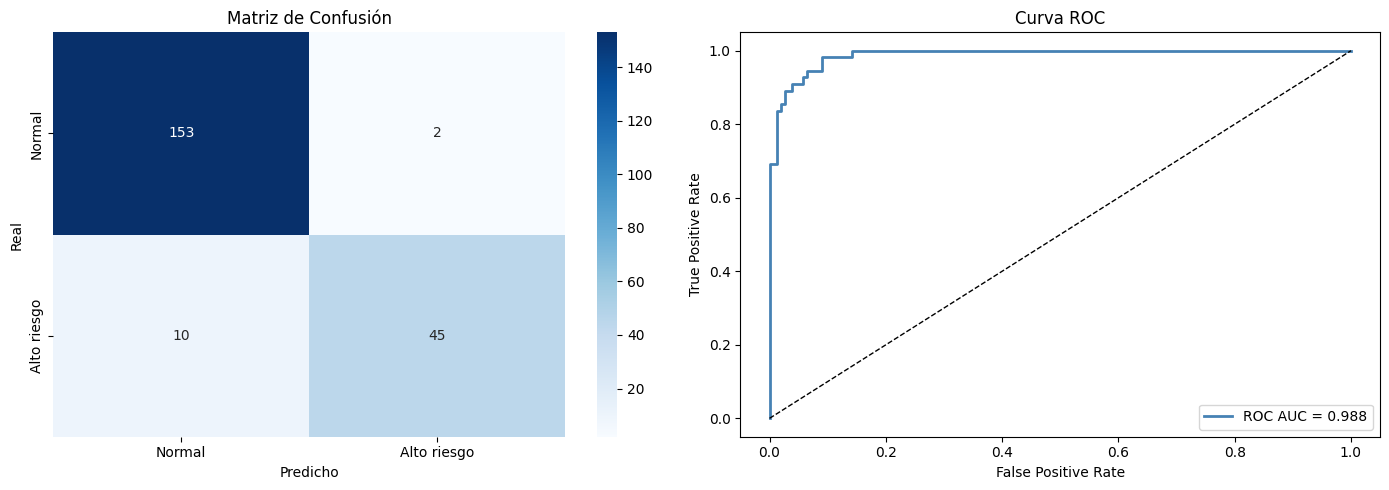

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Alto riesgo'],
            yticklabels=['Normal', 'Alto riesgo'],
            ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue',
             label=f'ROC AUC = {auc_score:.3f}', linewidth=2)
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_results.png', dpi=120, bbox_inches='tight')
plt.show()

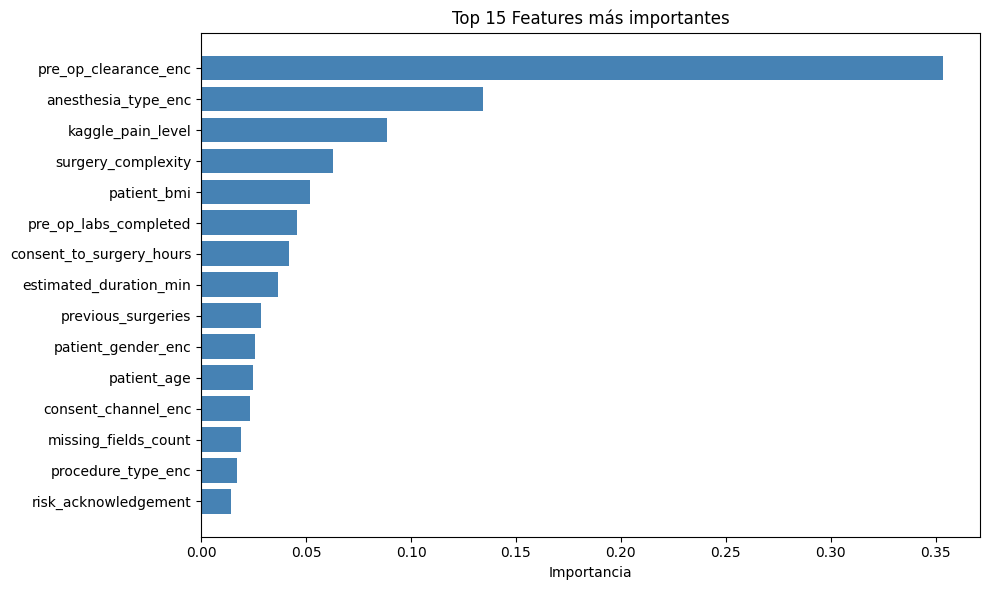


Top 5 features:
             feature  importance
         patient_bmi    0.051791
  surgery_complexity    0.062946
   kaggle_pain_level    0.088513
 anesthesia_type_enc    0.134442
pre_op_clearance_enc    0.353393


In [8]:
importance = pd.DataFrame({
    'feature':   FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('Top 15 Features más importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(importance.tail(5)[['feature','importance']].to_string(index=False))

In [9]:
import pickle
from datetime import datetime

model_path = f"risk_model_{datetime.now().strftime('%Y%m%d')}.pkl"
with open(model_path, 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURES}, f)

print(f"✓ Modelo guardado: {model_path}")
print(f"✓ ROC-AUC final: {roc_auc_score(y_test, y_proba):.4f}")
print("✓ Pipeline completo!")

✓ Modelo guardado: risk_model_20260422.pkl
✓ ROC-AUC final: 0.9880
✓ Pipeline completo!
